In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [15]:
df = pd.read_csv("../data/iris.csv")
df = df[df["iris_type"] != "Iris-virginica"]

# petal features 
X = df[["petal_length", "petal_width"]].to_numpy()
# setosa=0 versicolor=1
y = (df["iris_type"] == "Iris-versicolor").astype(int).to_numpy()

print("X shape:", X.shape)
print("y values:", np.unique(y))

X shape: (100, 2)
y values: [0 1]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("train:", X_train.shape)
print("test:", X_test.shape)

train: (80, 2)
test: (20, 2)


In [17]:
class Perceptron:   # im using this from the 1.1DL

    def __init__(self, n_inputs, lr=0.1, seed=12345):
        np.random.seed(seed)
        self.W = np.random.randn(n_inputs)
        self.b = 0.0
        self.lr = lr

    def activation(self, z):
        return 1 if z >= 0 else 0

    def predict(self, x):
        z = np.dot(self.W, x) + self.b
        return self.activation(z)

    def train(self, X, y, epochs=10):
        for _ in range(epochs):
            for xi, yi in zip(X, y):
                pred = self.predict(xi)
                error = yi - pred
                self.W += self.lr * error * xi
                self.b += self.lr * error
               

In [18]:
#starting here and messing with them later
model = Perceptron(n_inputs=2, lr=0.1)
model.train(X_train, y_train, epochs=10)
print("weights:", model.W)
print("bias:", model.b)

weights: [-0.06470766  0.66894334]
bias: -0.4


In [19]:
y_pred = np.array([model.predict(xi) for xi in X_test])
acc = accuracy_score(y_test, y_pred)
print("accuracy:", acc)
print("predicted:", y_pred)
print("actual:   ", y_test)

accuracy: 1.0
predicted: [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]
actual:    [1 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 1 1 0 0]


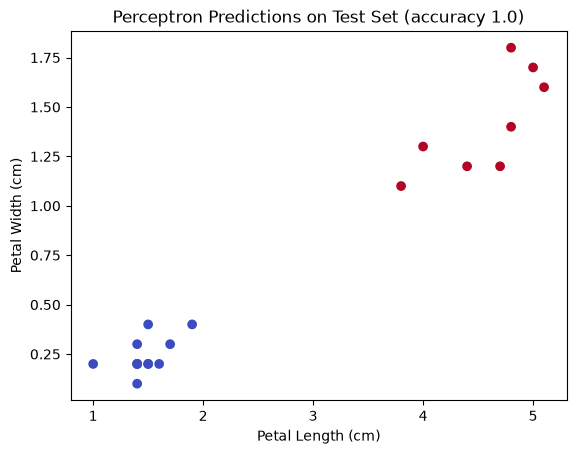

In [20]:
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap="coolwarm")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title(f"Perceptron Predictions on Test Set (accuracy {acc})")
plt.show()